In [1]:
from pathlib import Path
from yaml import safe_load
import numpy as np
import geopandas as gp
from copy import copy
import yaml
import sys
import subprocess
import datetime
# get the current date and time
now = datetime.datetime.now()

# clawpack 
from clawpack.visclaw import gridtools
from clawpack.pyclaw.solution import Solution

# matplotlib
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap

# Adresse du dossier 
proj_dir  = Path.cwd()
# Chargement du module AVAC
sys.path.insert(0, str(proj_dir / "AVAC"))
from module_avac import reading_raster_file_features, reload_avac, reading_raster_file 
from module_avac import export_raster, export_claw_dem, export_claw_dem_window, determine_file_type, plot_topo

# Chargement du module Waves
from module_waves import reload_wave, format_m
from module_waves import create_boundary_conditions
from module_waves import create_mask
from module_waves import check_domain_in_topo
from module_waves import modify_spillway_elevation

# latex
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size']   = 12
plt.rcParams['text.latex.preamble'] = r'\usepackage{libertine}'
# paramètre d'export des figures
figure_export_params = dict(dpi = 300, bbox_inches = 'tight')


In [2]:
# répertoires de travail
avac_output_dir = proj_dir/f"AVAC/_output"
avac_dir        = proj_dir / "AVAC"
BC_dir          = proj_dir / "CL"
topo_dir        = proj_dir / "Topo"
images_dir      = proj_dir / "Figures"
export_dir      = proj_dir / "Topo"
print(f"Répertoire du projet : {proj_dir}")
print(f"- répertoire AVAC : {avac_dir}")
print(f"- répertoire des conditions limites : {BC_dir}")
print(f"- répertoire des fichiers topo : {topo_dir}")
print(f"- répertoire des figures : {images_dir}")
print(f"- répertoire d'export : {export_dir}")
Path(images_dir).mkdir(exist_ok=True)
Path(export_dir).mkdir(exist_ok=True)

########################
# paramètres du calcul #
########################
# Attention le dictionnaire des paramètres est modifié en fonction des besoins ci-dessous
topo_files = {'coarse':'topo2m_c.asc','fine':'topo1m_simple.asc','mask_shp':'masque.shp','mask_raster':'mask.asc','missing_value':-9999}

lake       = {'topography':topo_files['fine'], # clawpack-comptatible topography for the computations
              'water_level': 1532.24,          # niveau d'eau
              'xmin':965670,'xmax':965850,'ymin':6536050,'ymax':6536300
              }

computation= {
    'damping': 0.3, # densité de la neige rho_a/rho
    'mode':'bc',    # source ou bc
    'cell_size':1,  # taille de la maille de calcul
    't_0':30,       # début de simulation
    't_max':150,    # fin de la simulation
    'nb_simul':120, # nombre de sauvegarde
    'nb_grid':400,  # nombre de maille pour l'interpolation de certaines grilles dans Waves post-process
    'output_directory':'_output', # pour mémoire
    'limiter':'mc','track_mass':True,'mass_frac_stop':0.01,'force_stop':False, \
               'mass_threshold_velocity':.01, 'initial_mass':False,
                'cfl_target':0.5,'cfl_max':1,\
               'refinement':1,'max_iter':100000, 'boundary':'user','dry_limit':0.0001}

dict_gauges = {'gauge_recording':False} # les jauges sont introduites plus bas

rheology    = {'Strickler':[10,30],                             # valeurs des coefficients de Strickler. Ici K = 10 pour z > water_level
               'friction_break_elevation':lake['water_level'],  # liste des altitude
               'friction':True,'friction_depth_limit':20,'wave_tolerance_flag':0.2,'rho':1000,'gravity':9.81}

output      = {'delta_t':1,'output_format':'binary', # ascii or binary
               'verbosity':0,                        # verbosité des fonctions de traitement
               'Language': 'French',                 # langue des figures. L'anglais n'est pas encore implanté
               'output_directory':'_output',         # pour des raisons de compatibilité avec des versions futures
               'carto_layout':                       # mise en forme des cartes
                    {'major_label_step':500,         # espacement entre coordonnées des axes pour les grandes cartes
                     'minor_label_step':50,          # espacement entre coordonnées pour les cartes agrandies
                     'margin':100}}                  # marge entre le cadre (domaine de calcul) et cadre des coordonnées

scenario    = {'period_return':100}                  # utile pour choisir le bon répertoire _output d'AVAC

directory   = {'project_directory':str(proj_dir)}

date = {'date':now}
# Assemblage des dictionnaires
parameters  = {'topo_files':topo_files,'lake':lake ,'computation':computation,'gauges':dict_gauges, 
               'rheology':rheology, 'output':output, 'date':date, 'scenario':scenario, 'directory': directory}
# Sauvegarde du fichier de configuration
file_name = 'impulse_configuration.yaml'
with open(file_name, 'w') as file:
    yaml.dump(parameters, file)

print(f"Ficher de configuration {file_name} sauvegardé")

# sauvegarde de la configuraiton
with open(proj_dir / "impulse_configuration.yaml") as file:
    config = safe_load(file)
    topo = config["topo_files"]
    lake = config["lake"]

# lecture de la configuration d'AVAC
with open(avac_dir / "AVAC_configuration.yaml") as file:
    avac_config = safe_load(file)
    avac_output = config["output"]

avac_period = avac_config['release']['period_return']
wave_period = config['scenario']['period_return']
print(f"Période de retour considérée :\n * T= {avac_period} ans pour AVAC \n * T= {wave_period} ans pour Wave")
print(f"Répertoire de résultats : \n* AVAC : {avac_config['output']['output_directory']}\n* Wave : {output['output_directory']}")
     

Répertoire du projet : /home/ancey/Lac_Clusaz
- répertoire AVAC : /home/ancey/Lac_Clusaz/AVAC
- répertoire des conditions limites : /home/ancey/Lac_Clusaz/CL
- répertoire des fichiers topo : /home/ancey/Lac_Clusaz/Topo
- répertoire des figures : /home/ancey/Lac_Clusaz/Figures
- répertoire d'export : /home/ancey/Lac_Clusaz/Topo
Ficher de configuration impulse_configuration.yaml sauvegardé
Période de retour considérée :
 * T= 300 ans pour AVAC 
 * T= 100 ans pour Wave
Répertoire de résultats : 
* AVAC : _output300
* Wave : _output


# Jauges

In [3]:
# Si gauge_recording, alors lire le fichier shapefile (points) avec jauges
# pour l'heure les cartes ne prévoient que 4 jauges
gauge_recording = True
if gauge_recording:
    # Read the shapefile
    pts = gp.read_file(topo_dir / 'jauges.shp')
    nb_pts = len(pts)
    nb_pts
    dict_gauges = {'gauge_recording':True}
    for i in range(nb_pts):
        x = pts.geometry[i].coords.xy[0][0]
        y = pts.geometry[i].coords.xy[1][0]
        print(f"jauge n° {i+1} : x = {format_m(x)} m et y = {format_m(y)} m")
        dict_gauges[str(i)]={'x':float(x), 'y':float(y)}
        parameters['gauges'] = dict_gauges
    # sauvegarde
    file_name            = 'impulse_configuration.yaml'
    with open(file_name, 'w') as file:
        yaml.dump(parameters, file)
    print(f"Fichier de configuration {file_name} mis à jour...")
else:
    print("pas de jauges !")

jauge n° 1 : x = 965 730.7 m et y = 6 536 144.6 m
jauge n° 2 : x = 965 762.0 m et y = 6 536 170.1 m
jauge n° 3 : x = 965 768.0 m et y = 6 536 209.1 m
jauge n° 4 : x = 965 775.9 m et y = 6 536 243.3 m
Fichier de configuration impulse_configuration.yaml mis à jour...


# Création du masque et de la topo_fine

In [4]:
# Un masque est nécessaire pour définir la hauteur initiale dans le lac
# Lecture de la topo et vérification de la consistance du domaine de calcul avec la topo dispo
# On teste également la compatibilité du fichier (raster) topographique du lac pour geoclaw
topo_fine = reading_raster_file(str(topo_dir / topo_files['fine']))
xmin, xmax, ymin, ymax, nbx, nby, cell_size, dictionary_domain, failure, remarks, grid_type  = \
        reading_raster_file_features(topo_dir / lake['topography'])

print(f"* xmin = {xmin} m et xmax = {xmax} m ; nbx = {nbx} ; dx = {cell_size} m")
print(f"* ymin = {ymin} m et ymax = {ymax} m ; nby = {nby} ; dy = {cell_size} m")
print(f"* type de grille = {grid_type}  ")
print(f"* format de grille = {determine_file_type(topo_dir / lake['topography'])}  ")


* xmin = 965000.20001221 m et xmax = 967998.20001221 m ; nbx = 2999 ; dx = 1.0 m
* ymin = 6535001.08996582 m et ymax = 6536999.08996582 m ; nby = 1999 ; dy = 1.0 m
* type de grille = cell  
* format de grille = esri  


In [5]:
# Test de compatibilité
print(f"Le fichier topo pour le calcul des vagues est {topo_files['fine']}")
print(f"Ce fichier est de type {determine_file_type(str(topo_dir / topo_files['fine']))}.")
if determine_file_type(str(topo_dir / topo_files['fine'])) != 'claw':
    print(f"Attention : le fichier topographique n'est pas compatible avec geoclaw !")
    print("Conversion vers le format clawpack et transfert vers topography_lake.asc...")
    lake['topography']               = 'topography_lake.asc'
    parameters['lake']['topography'] = 'topography_lake.asc'
    parameters['topo_files']['added_clawpack-compatible_topo'] = 'topography_lake.asc'
    file_name                        = 'impulse_configuration.yaml'
    export_claw_dem(xmin,xmax,ymin,ymax,nbx,nby,topo_fine.Z, name_file=str(topo_dir / 'topography_lake.asc'))
    with open(file_name, 'w') as file:
        yaml.dump(parameters, file)
    print("Mise à jour du fichier de configuration effectuée.")
else:
    print("Le fichier topographique est compatible avec geoclaw. Je le conserve.")
check_domain_in_topo(lake, xmin, xmax, ymin, ymax)

Le fichier topo pour le calcul des vagues est topo1m_simple.asc
Ce fichier est de type esri.
Attention : le fichier topographique n'est pas compatible avec geoclaw !
Conversion vers le format clawpack et transfert vers topography_lake.asc...
* Export du MNT vers le raster /home/ancey/Lac_Clusaz/Topo/topography_lake.asc.
Mise à jour du fichier de configuration effectuée.
Le domaine de calcul des vagues est entièrement contenu dans le fichier topography_lake.asc.


## Export du masque

Rasterisation du shapefile `masque.shp` sur la grille final du lac. Attention à la convention choisie :
- **0** -> intérieur du polygone (lac)  
- **1** -> extérieur (zones sèches)

In [6]:
# création du masque
create_mask(proj_dir,topo_dir,topo_files,lake,erase=False,mask_cell_size=computation['cell_size'])

0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 2999, 1999
0...10...20...30...40...50...60...70...80...90...100 - done.
* Export du MNT vers le raster /home/ancey/Lac_Clusaz/Topo/mask.asc.
J'ai gardé le fichier temporaire masque.asc (comptatible qgis).
Masque créé : /home/ancey/Lac_Clusaz/Topo/mask.asc


### Vue du masque sur le MNT complet

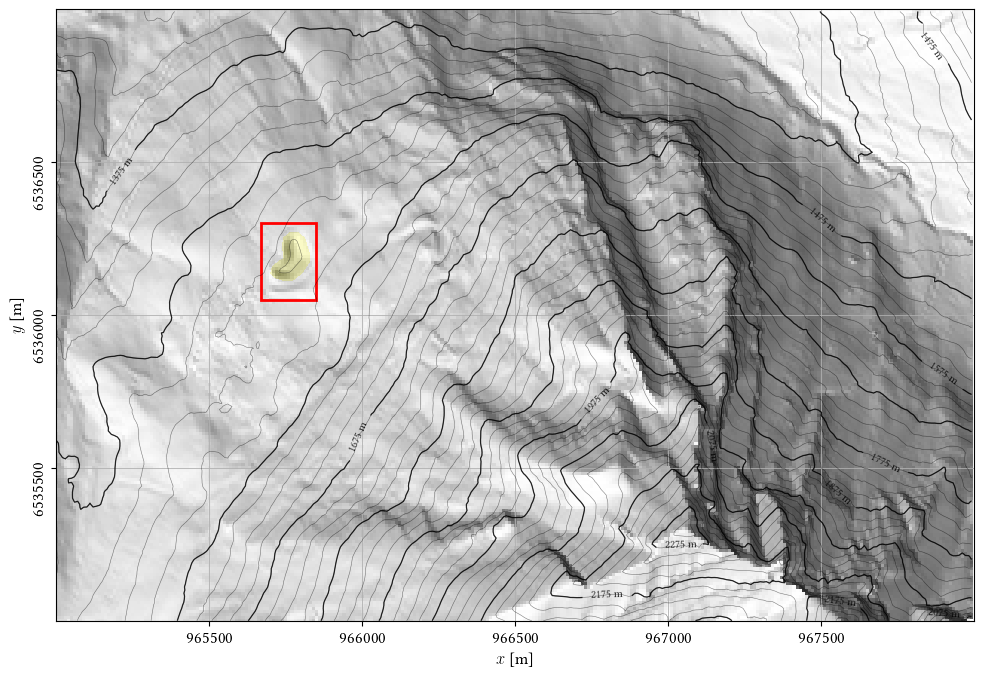

In [7]:
# Ensemble des données topo
mask_file  = reading_raster_file(topo_dir / 'mask.asc')
masked_dem = np.ma.masked_invalid(mask_file.Z)# Mask NaN values
topo_file  = reading_raster_file(topo_dir / lake['topography'])

# rééchantillonnage
resampling        = True        # afin de réduire le temps d'affichage on peut réchantillonner les raster
sampling_factor   = 10   # valeur rééchantillonnage  
# espacement entre les coordonnées géographiques affichées sur la carte
major_label_step  = output['carto_layout']['major_label_step']   
# mettre à jour le dictionnaire si on change cette valeur de major_step_label
if major_label_step != parameters['output']['carto_layout']['major_label_step']:
    parameters['output']['carto_layout']['major_label_step'] = major_label_step
    with open(file_name, 'w') as file:
        yaml.dump(parameters, file)

if resampling:
    topo_file_resampled   = copy(topo_file)
    topo_file_resampled.Z = topo_file.Z[::sampling_factor, ::sampling_factor]
    topo_file_resampled.x = topo_file.x[::sampling_factor]
    topo_file_resampled.y = topo_file.y[::sampling_factor]
    fig, ax, x0, y0 = plot_topo(topo_file_resampled, step=major_label_step)
else:
    fig, ax, x0, y0 = plot_topo(topo_file,step=major_label_step)

# figure
ax.add_patch(plt.Rectangle((lake['xmin']-x0,lake['ymin']-y0) , width=lake['xmax']-lake['xmin'], 
                           height=lake['ymax']-lake['ymin'], ls="-", lw=2, ec="red", fc="none"))

cmap_mask = ListedColormap([(1, 1, 0, 1),    # index 0 : jaune opaque
                            (0, 0, 0, 0)])   # index 1 : transparent

plt.imshow(masked_dem, origin='lower',
           extent=[xmin-xmin, xmax-xmin, ymin-ymin, ymax-ymin],
           cmap=cmap_mask, vmin=0, vmax=1)

if resampling:
    fig.savefig(images_dir / "vue_densemble_LR.png", **figure_export_params)
else:
    fig.savefig(images_dir / "vue_densemble.png", **figure_export_params)

### Vue du masque sur la carte zoomée

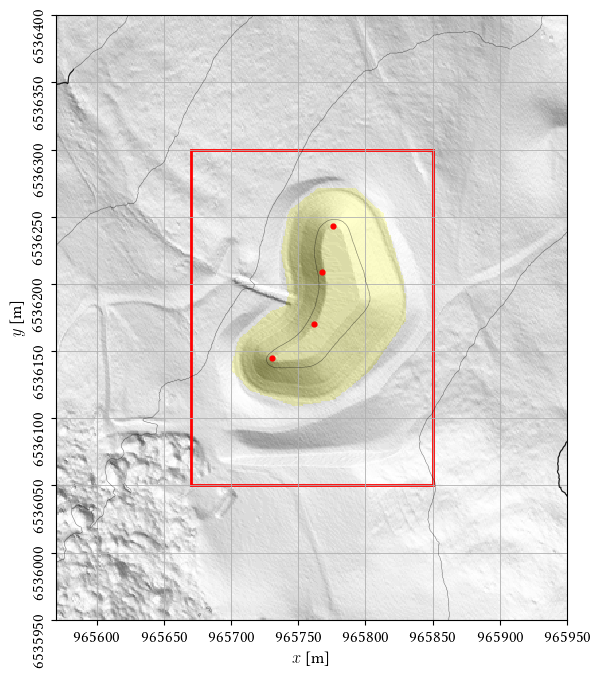

In [8]:
# zoom sur le lac
# espacement entre les coordonnées géographiques affichées sur la carte
minor_label_step = parameters['output']['carto_layout']['minor_label_step']   
# mettre à jour le dictionnaire si on change cette valeur de major_step_label
if major_label_step != parameters['output']['carto_layout']['minor_label_step']:
    parameters['output']['carto_layout']['minor_label_step'] = minor_label_step
    with open(file_name, 'w') as file:
        yaml.dump(parameters, file)

resampling = False
# figure
if resampling:
    fig, ax, x0, y0 = plot_topo(topo_file_resampled, step=minor_label_step)
else:
    fig, ax, x0, y0 = plot_topo(topo_file,step=minor_label_step)
ax.add_patch(plt.Rectangle((lake['xmin']-x0, lake['ymin']-y0),
                            width=lake['xmax']-lake['xmin'],
                            height=lake['ymax']-lake['ymin'],
                            ls="-", lw=2, ec="red", fc="none"))
 
cmap_mask = ListedColormap([(1, 1, 0, 1), (0, 0, 0, 0)])
plt.imshow(masked_dem, origin='lower',
           extent=[xmin-xmin, xmax-xmin, ymin-ymin, ymax-ymin],
           cmap=cmap_mask, vmin=0, vmax=1)

# Zoom sur le lac avec une marge
margin = parameters['output']['carto_layout']['margin']  # mètres
ax.set_xlim(lake['xmin'] - x0 - margin, lake['xmax'] - x0 + margin)
ax.set_ylim(lake['ymin'] - y0 - margin, lake['ymax'] - y0 + margin)
for k in range(len(dict_gauges)-1):
    x = dict_gauges[str(k)]['x']
    y = dict_gauges[str(k)]['y']
    plt.scatter(x-x0,y-y0,c = 'red',marker='o',s=12)
if resampling:
    fig.savefig(images_dir / "vue_rapprochée_LR.png", **figure_export_params)
else:
    fig.savefig(images_dir / "vue_rapprochée.png", **figure_export_params)


# Création et insertion d'un seuil ou dun barrage

Cette fonctoon de permet de modifier localement le MNT :
* il faut placer un shapefile de type polyligne représentant l'axe du barrage ou du seuil dans le répertoire /Topo
* on considère une bande centrée sur cet axe avec une demie largeur `half_width`
* l'altitude du couronnement est `new_altitude`. Attention l'interpolation du MNT tend à modifier cette cote.

In [9]:

topo_file_modified = modify_spillway_elevation(
    topo_file       = topo_file,
    shapefile_path  = topo_dir / 'seuil.shp',   #  polyligne QGIS
    half_width      = 1,   # ± 1 m autour de l'axe
    new_altitude    = 1532.5  # nouvelle cote du seuil  
)


* Seuil mis à 1532.500 m sur 13 cellule(s) (bande de ±1.0 m autour de la polyligne).


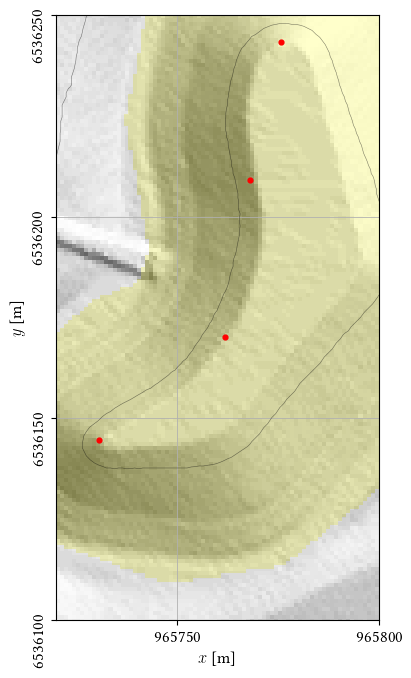

In [10]:
resampling = False
# figire
if resampling:
    fig, ax, x0, y0 = plot_topo(topo_file_resampled, step=50)
else:
    fig, ax, x0, y0 = plot_topo(topo_file_modified,step=50)

# domaine de calcul
ax.add_patch(plt.Rectangle((lake['xmin']-x0, lake['ymin']-y0),
                            width=lake['xmax']-lake['xmin'],
                            height=lake['ymax']-lake['ymin'],
                            ls="-", lw=2, ec="red", fc="none"))

# masque du lac
cmap_mask = ListedColormap([(1, 1, 0, 1), (0, 0, 0, 0)])
plt.imshow(masked_dem, origin='lower',
           extent=[xmin-xmin, xmax-xmin, ymin-ymin, ymax-ymin],
           cmap=cmap_mask, vmin=0, vmax=1)

# Zoom sur le lac avec une marge
margin = -50  # mètres
ax.set_xlim(lake['xmin'] - x0 - margin, lake['xmax'] - x0 + margin)
ax.set_ylim(lake['ymin'] - y0 - margin, lake['ymax'] - y0 + margin)
# jauges
for k in range(len(dict_gauges)-1):
    x = dict_gauges[str(k)]['x']
    y = dict_gauges[str(k)]['y']
    plt.scatter(x-x0,y-y0,c = 'red',marker='o',s=12)

fig.savefig(images_dir / "vue_rapprochée_seuil_lac.png", **figure_export_params)

In [11]:
# export et modification du dictionnaire de paramètres 
print("Conversion vers le format clawpack et transfert vers topography_lake.asc...")
lake['topography']               = 'topography_lake_with_weir.asc'
parameters['lake']['topography'] = 'topography_lake_with_weir.asc'
parameters['topo_files']['added_clawpack-compatible_topo'] = 'topography_lake_with_weir.asc'
file_name                        = 'impulse_configuration.yaml'
export_claw_dem(xmin,xmax,ymin,ymax,nbx,nby,topo_file_modified.Z, name_file=str(topo_dir / 'topography_lake_with_weir.asc'))

# sauvegarde du fichier de configuration
with open(file_name, 'w') as file:
    yaml.dump(parameters, file)

# export du raster pour qgis
# le fichier raster topography_lake_with_weir.asc est compatible avec geoclaw, mais non avec qgis. 
# il est possible de faire un export du raster pour un usage dans qgis
save_for_qgis = False
if save_for_qgis:
    export_raster(topo_dir / 'topography_lake_with_weir_qgis.asc',topo_file_modified.Z.T,x0,y0,cell_size)

Conversion vers le format clawpack et transfert vers topography_lake.asc...
* Export du MNT vers le raster /home/ancey/Lac_Clusaz/Topo/topography_lake_with_weir.asc.


# Création des conditions aux limites

In [15]:
reload_wave()
from module_waves import create_boundary_conditions

Module reloaded successfully.


In [12]:
# on définiti le dossier d'AVAC à partir de la période de retour du scénario
# Attention : il s'agit d'une modification locale
avac_config['output']['output_directory'] = '_output'+str(parameters['scenario']['period_return'])
avac_output_dir  = avac_dir / avac_config['output']['output_directory']
if avac_output_dir.exists():
    h_dict, q_dict, flux_dict, times = create_boundary_conditions(proj_dir,lake,BC_dir, 
                                                              damping  =  computation['damping'], 
                                                              avac_out = avac_config['output']['output_directory'])
else:
    print(f"Le répertoire {avac_output_dir} n'existe pas. Il faut renseigner avac_config['output']['output_directory']")

J'ai trouvé 151 fichiers de simulation AVAC dans /home/ancey/Lac_Clusaz/AVAC/_output100
Format des données de simulations : binary32
J'ai sauvé le fichier /home/ancey/Lac_Clusaz/CL/summary_config.yaml.
Sauvegarde du fichier  151/151...
J'ai généré les conditions aux limites entre les temps  t = 0.0 s et t = 150.0.


## Débit entrant dans le domaine

Flux entrant dans le domaine de calcul du lac, avec un coefficient de transfert de qdm = 0.3
Volume total entrant par la frontière est : 2 514.1 m³


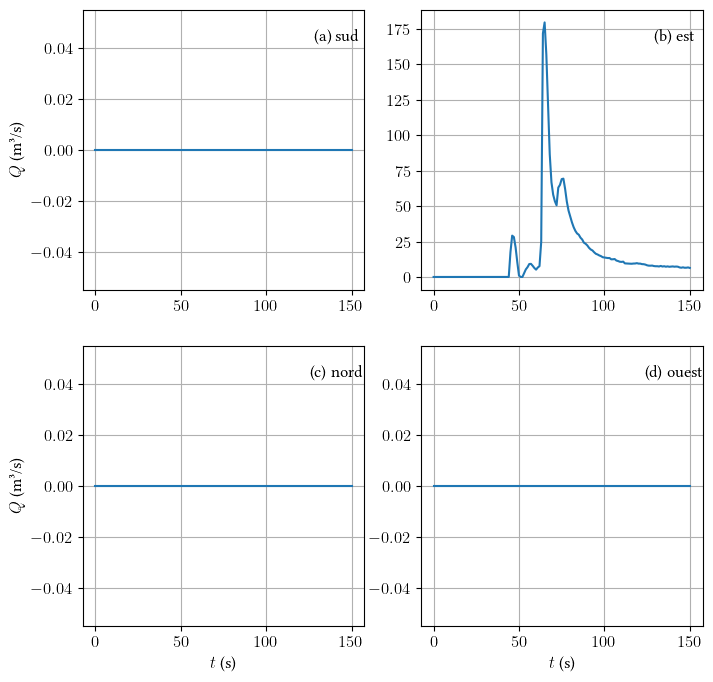

In [13]:
# Variation du débit entrant
# Les fichiers dans le répertoire CL sont les valeurs brutes tirées d'AVAC
# On montre ici ce à quoi cela correspond quand on applique le facteur d'amortissement
# les flux entrants sont > 0 et < 0 s'ils sont sortants
print(f"Flux entrant dans le domaine de calcul du lac, avec un coefficient de transfert de qdm = {computation['damping']}")
fig, ((ax1, ax2 ),(ax3, ax4 )) = plt.subplots(2,2)
fig.set_figheight(8)
fig.set_figwidth(8)
dict_boundary = {'bottom':'(a) sud', 'right':'(b) est', 'top':'(c) nord', 'left':'(d) ouest'}
 
boundaries = list(dict_boundary.keys())
axes_list =  (ax1,ax2,ax3,ax4)
for b, ax in zip(boundaries,axes_list):
    ax.plot(times,-np.array(flux_dict[b]))
    #ax.text()
    plt.text(0.9, 0.9, dict_boundary[b],
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes)
for ax in (ax3,ax4):
    ax.set_xlabel(r"$t$ (s)")
for ax in (ax1,ax3):
    ax.set_ylabel(r"$Q$ (m³/s)")
for ax in (ax1,ax2,ax3,ax4):
    ax.grid()
#plt.tight_layout()
fig.savefig(images_dir / "flux.png",**figure_export_params)
dt = times[1]-times[0]
volume_total = -np.array(flux_dict['right']).sum()*dt
print(f"Volume total entrant par la frontière est : {format_m(volume_total)} m³")

## Hauteur aux frontières du domaine

Hauteurs aux frontières du domaine de calcul du lac, avec un coefficient de transfert de qdm = 0.3


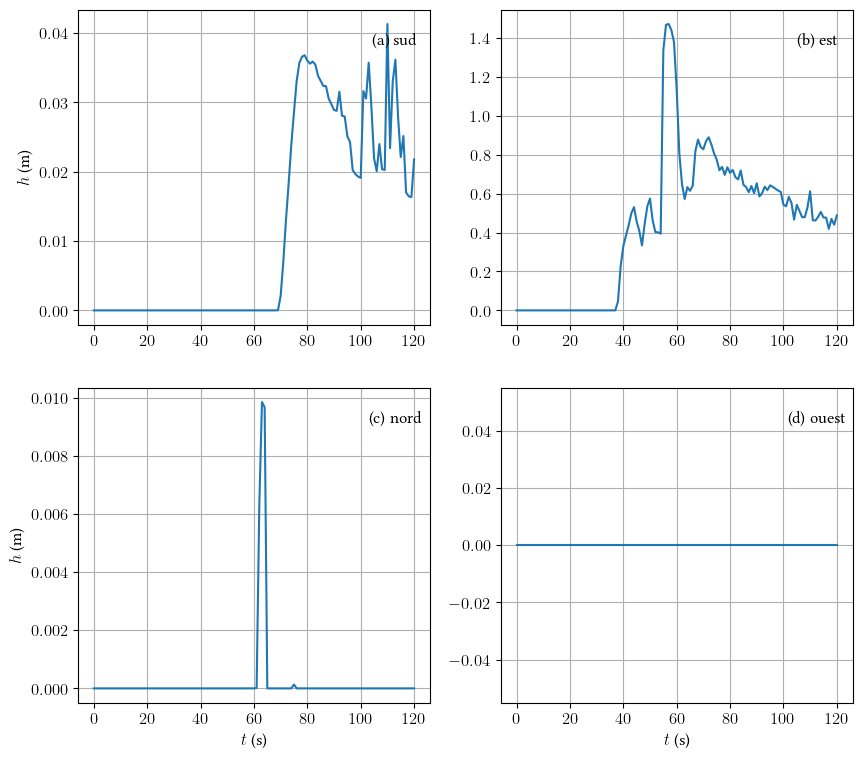

In [ ]:
print(f"Hauteurs aux frontières du domaine de calcul du lac, avec un coefficient de transfert de qdm = {computation['damping']}")
fig, ((ax1, ax2 ),(ax3, ax4 )) = plt.subplots(2,2)
fig.set_figheight(9)
fig.set_figwidth(10)
dict_boundary = {'bottom':'(a) sud', 'right':'(b) est', 'top':'(c) nord', 'left':'(d) ouest'}
 
boundaries = list(dict_boundary.keys())
axes_list =  (ax1,ax2,ax3,ax4)
for b, ax in zip(boundaries,axes_list):
    ax.plot(times,h_dict[b])
    #ax.text()
    plt.text(0.9, 0.9, dict_boundary[b],
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes)
for ax in (ax3,ax4):
    ax.set_xlabel(r"$t$ (s)")
for ax in (ax1,ax3):
    ax.set_ylabel(r"$h$ (m)")
for ax in (ax1,ax2,ax3,ax4):
    ax.grid()
fig.savefig(images_dir / "hauteur_frontière_domaine.png", **figure_export_params)